Task 1: Titanic Survival Prediction

In [ ]:
# RUN 1: Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# RUN 2: Load downloaded Titanic CSV from Google Drive

file_path = "Titanic-Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# RUN 3: Check dataset details

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSurvival count:")
print(df["Survived"].value_counts())

Dataset shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival count:
Survived
0    549
1    342
Name: count, dtype: int64


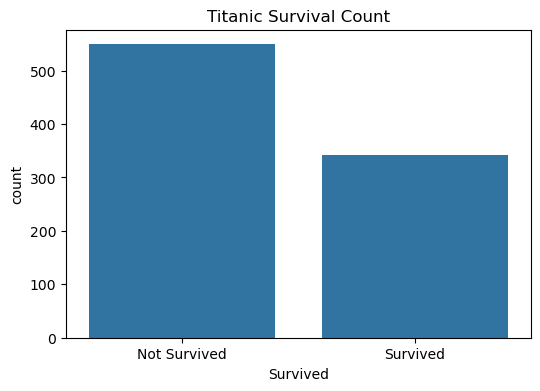

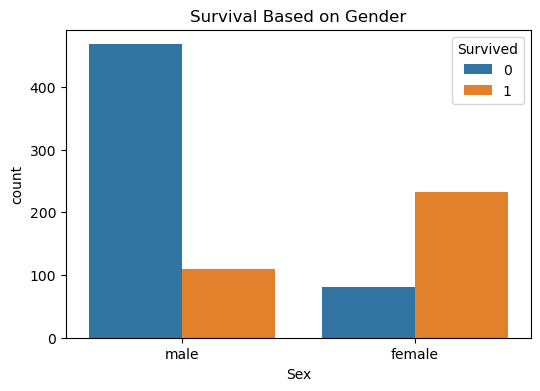

In [ ]:
# RUN 4: Visualize survival data

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Titanic Survival Count")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival Based on Gender")
plt.show()

In [ ]:
# RUN 5: Select useful columns and clean missing values

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[features].copy()
y = df["Survived"]

# Convert text columns into numbers
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Fill missing values
imputer = SimpleImputer(strategy="median")
X[["Age", "Fare"]] = imputer.fit_transform(X[["Age", "Fare"]])

X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

print("Data cleaned successfully!")
display(X.head())

Data cleaned successfully!


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0.0
1,1,1,38.0,1,0,71.2833,1.0
2,3,1,26.0,0,0,7.9250,0.0
3,1,1,35.0,1,0,53.1000,0.0
4,3,0,35.0,0,0,8.0500,0.0


In [ ]:
# RUN 6: Split data for training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [ ]:
# RUN 7: Train Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# RUN 8: Test model accuracy

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 81.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



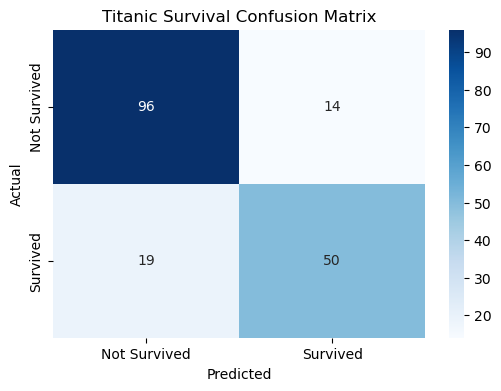

In [ ]:
# RUN 9: Show confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Titanic Survival Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()